# Exercise 3 — Verlet Method

## Theory

The Verlet method is a numerical integration method commonly used to solve second-order differential equations in dynamical systems. It is especially useful for orbital mechanics because the equations of motion are naturally expressed in terms of position and acceleration.

For a test body moving around a central mass $M$, the gravitational acceleration is

$$
\mathbf{a}
=
-\frac{GM}{r^3}\mathbf{r},
$$

where

$$
\mathbf{r}=(x,y)
$$

and

$$
r^2=x^2+y^2.
$$

Therefore, the acceleration components are

$$
a_x=-\frac{GMx}{(x^2+y^2)^{3/2}},
$$

$$
a_y=-\frac{GMy}{(x^2+y^2)^{3/2}}.
$$

The standard Verlet method calculates the new position using the current and previous positions:

$$
x_{n+1}
=
2x_n-x_{n-1}+a_x(x_n,y_n)h^2,
$$

$$
y_{n+1}
=
2y_n-y_{n-1}+a_y(x_n,y_n)h^2.
$$

Since the method requires two previous positions, the first step must be calculated separately using the initial position and velocity:

$$
x_1
=
x_0+v_{x,0}h+\frac{1}{2}a_x(x_0,y_0)h^2,
$$

$$
y_1
=
y_0+v_{y,0}h+\frac{1}{2}a_y(x_0,y_0)h^2.
$$

After the first step is initialized, the Verlet recurrence relation can be applied to calculate the orbital trajectory.

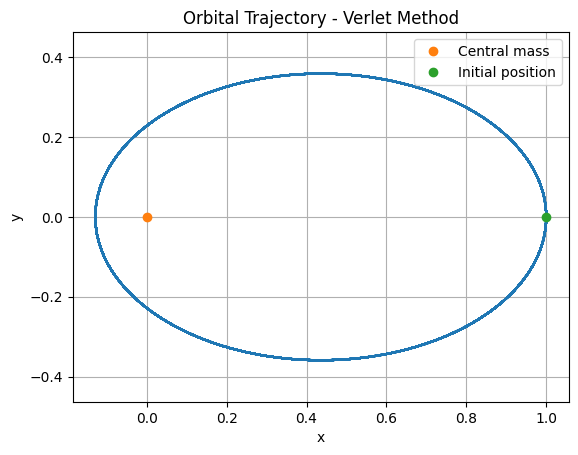

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parametros
G = 4*np.pi**2
M = 1

t_0 = 0
t_final = 20
n = 500000

h = (t_final-t_0)/n

# Tiempo
t = np.linspace(t_0,t_final,n)

# Posiciones
x = np.zeros(n)
y = np.zeros(n)

# Condiciones iniciales
x[0] = 1
y[0] = 0

vx_0 = 0
vy_0 = 3

# Aceleraciones
def ax(x,y):
  r2 = x**2 + y**2
  return -G*M*x/r2**(3/2)

def ay(x,y):
  r2 = x**2 + y**2
  return -G*M*y/r2**(3/2)

# Primer paso

x[1] = x[0] + vx_0*h + 0.5*ax(x[0],y[0])*h**2
y[1] = y[0] + vy_0*h + 0.5*ay(x[0],y[0])*h**2

# Metodo de Verlet

for i in range(1,n-1):

  x[i+1] = 2*x[i] - x[i-1] + ax(x[i],y[i])*h**2
  y[i+1] = 2*y[i] - y[i-1] + ay(x[i],y[i])*h**2

# Grafica

plt.plot(x,y)
plt.plot(0,0,'o',label='Central mass')
plt.plot(x[0],y[0],'o',label='Initial position')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Orbital Trajectory - Verlet Method")
plt.axis("equal")
plt.grid()
plt.legend()

plt.show()

## Conclusion

The Verlet method successfully reproduces the orbital motion of the test body around the central mass. Unlike methods that explicitly evolve both position and velocity, the standard Verlet method calculates each new position using the two previous positions and the current acceleration.

The method requires a separate initialization of the first position using the initial velocity and acceleration. After this initialization, the trajectory can be obtained directly from the Verlet recurrence relation.

Because the gravitational acceleration depends on the current position, it is recalculated at every iteration of the numerical solution.